# Simulación Avanzada

## Simulación Monte Carlo

Kevin Ferney Hidalgo Higuita
kfhidalgoh@unal.edu.co
Repositorio [GitHub](https://github.com/thepadr30/SimulAva3010192)


### Librerías y configuraciones iniciales

In [1]:
import logging
import os
import sys
import warnings
from time import localtime, strftime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML
from IPython.display import Image, display

from src.graph.fun_graph_matplotlib import FnGraphMat
from src.logs.logger import setup_logging
from src.utils import statisticsBase as sB
from src.ipynb.estiloDashboard import estilo_dashboard, estilo_dashboard_v0, estilo_dashboard_v2

In [2]:
__authors__ = ["Kevin Hidalgo"]
__contact__ = "kfhidalgoh@unal.edu.co"
__copyright__ = "Copyright 2026"
__credits__ = ["Kevin Hidalgo"]
__email__ = "kfhidalgoh@unal.edu.co"
__status__ = "Desarrollo"
__version__ = "1.0.0"
__date__ = "2026-02-23"
__file__ = "SimulacionMCIpynb"

file_log = os.path.join('D:\SimulAva\logs', strftime("%Y%m%d%H%M%S", localtime()) + "_" + __file__ + ".log" )

logger = setup_logging(file_log)
logging.info("Python %s on %s", sys.version, sys.platform)
logging.info("Root: %s", os.getcwd())  # os.path.abspath(os.curdir)
logging.info("Log: %s", file_log)

##############
# Constantes #
##############

varData = r'D:\SimulAva\data\raw'
grmt = FnGraphMat('seaborn-v0_8-darkgrid')  # seaborn-v0_8-darkgrid, dark_style
sns.set_palette("husl")
warnings.filterwarnings('ignore')
np.random.seed(2026)
%matplotlib inline

2026-03-08 15:04:09 [INFO]: Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)] on win32
2026-03-08 15:04:09 [INFO]: Root: D:\SimulAva\notebooks
2026-03-08 15:04:09 [INFO]: Log: D:\SimulAva\logs\20260308150409_SimulacionMCIpynb.log


## Lectura / Creación de datos

En este paso recrearemos los datos del enunciado, hay varias formas de hacerlo, una es mediante la lectura de un archivo excel, otra es crear los arreglos y convertirlos en un dataframe, es importante tener en cuenta que los datos del enunciado corresponde a una tabla de frecuencias, pero se puede hacer ingeniería inversa, es decir, pasar de la tabla de frecuencias (datos agrupados) al *registro histórico diario original* (datos crudos)

In [4]:
# 1. Definir los datos agrupados que nos da el documento
ventas_cajas = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
numero_dias = np.array([1, 5, 12, 19, 27, 59, 74, 59, 49, 37, 22])
tabla_freq = pd.DataFrame({
    'Ventas': ventas_cajas,
    'Dias': numero_dias
})

# 2. Recrear los datos crudos (expansión de frecuencias)
# np.repeat tomará el '0' y lo pondrá 1 vez, el '1' 5 veces, el '2' 12 veces, etc.
bitacora_historica = np.repeat(ventas_cajas, numero_dias)

# 3. Mezclar los datos para simular el registro cronológico diario (serie de tiempo real)
np.random.shuffle(bitacora_historica)

# 4. Crear el DataFrame simulando el registro diario original de las 52 semanas
df_registro_diario = pd.DataFrame({
    'Dia_Historico': range(1, 365),
    'Demanda_Observada': bitacora_historica
})

### Tabla de Frecuencias

In [5]:
estilo_dashboard_v0(tabla_freq)

Ventas,Dias
0,1
1,5
2,12
3,19
4,27
5,59
6,74
7,59
8,49
9,37


### Registro diario

In [6]:
# primeros 5 registros
estilo_dashboard_v0(df_registro_diario.head(5))

Dia_Historico,Demanda_Observada
1,9
2,2
3,7
4,9
5,1


In [7]:
HTML(f"""
<div style="font-family:Arial">

<h1 style="text-align:center">Ventas cajas de leche</h1>

<div style="display:flex; justify-content:space-around">

<div style="font-size:24px">
<h3>Registro Diario (primeros 5 registros)</h3>
{df_registro_diario.head().to_html(index=False)}
</div>

<div style="font-size:24px">
<h3>Frecuencias</h3>
{tabla_freq.to_html(index=False)}
</div>

</div>

</div>
""")

Dia_Historico,Demanda_Observada
1,9
2,2
3,7
4,9
5,1
Ventas,Dias
0,1
1,5
2,12
3,19


## Análisis exploratorio de datos (EDA)

En este apartado podemos trabajar sobre el registro diario

In [8]:
# veamos que tienen las columnas
estilo_dashboard(sB.column_overview(df_registro_diario))

,dtype,missing_count,unique_count
Dia_Historico,int64,0.00,364.00
Demanda_Observada,int64,0.00,11.00


In [9]:
# veamos estadísticas básicas sobre las columnas
# sB.numeric_descriptive_stats(df_registro_diario).round(2)
estilo_dashboard(sB.numeric_descriptive_stats(df_registro_diario), decimals=2)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,median,missing
Dia_Historico,364.00,182.50,105.22,1.00,4.63,19.15,37.30,91.75,182.50,273.25,327.70,345.85,360.37,364.00,182.50,0.00
Demanda_Observada,364.00,6.29,2.10,0.00,1.00,3.00,3.30,5.00,6.00,8.00,9.00,10.00,10.00,10.00,6.00,0.00


Nuestro interés se concentra en la variable _Demanda Observada_, tener presente que son ventas de cajas
* 6.29 cajas/día → 44.06 cajas/semana, lo que ya anticipa que el contrato actual de 30 cajas/semana es insuficiente.
* mean y median son cercanas
* std 2.1
* min 0, max 10

Haciendo zoom en nuestra variable de interes

In [10]:
df_stats = sB.fn_statistics_base(df_registro_diario, 'Demanda_Observada')
# print(df_stats.T)
# df_stats
estilo_dashboard(df_stats)

,n_total,n_obs,missing_count,mean,median,var,std,sem,min,max,range,CV_pct,q1,q3,iqr,skewness,kurtosis,ci_mean_lower,ci_mean_upper
0,364.00,364.00,0.00,6.29,6.00,4.41,2.10,0.11,0.00,10.00,10.00,33.35,5.00,8.00,3.00,-0.29,-0.26,6.08,6.51


* kurtosis = -0.26: La distribución es más plana y dispersa, con colas más delgadas o ligeras, indicando menos valores atípicos y menor concentración en la media.
* Skewness = -0.29: La cola izquierda es más larga; los datos se concentran a la derecha (valores altos), con algunos valores atípicos bajos.
* Porcentaje coeficiente de variacion 33.35%: Esto sugiere que las ventas presentan una variabilidad moderada a alta respecto a su media.

### Outlier

Se aplica el rango intercuartil (IQR) sobre los datos, aquellos datos que sobrepasen los límites serán considerados como datos atípicos o Outliers.

In [11]:
dict_out = sB.detectar_outliers(
    df_registro_diario,
    variable_target='Demanda_Observada'
)


=== DETECCIÓN DE OUTLIERS (MÉTODO IQR) ===

--- Demanda_Observada ---
Límites IQR: [0.50, 12.50]
Outliers detectados: 1 (0.27%)
Valores outliers: [0]


* es el día en que hubo 0 ventas de cajas de leche.

### Histograma & Boxplot

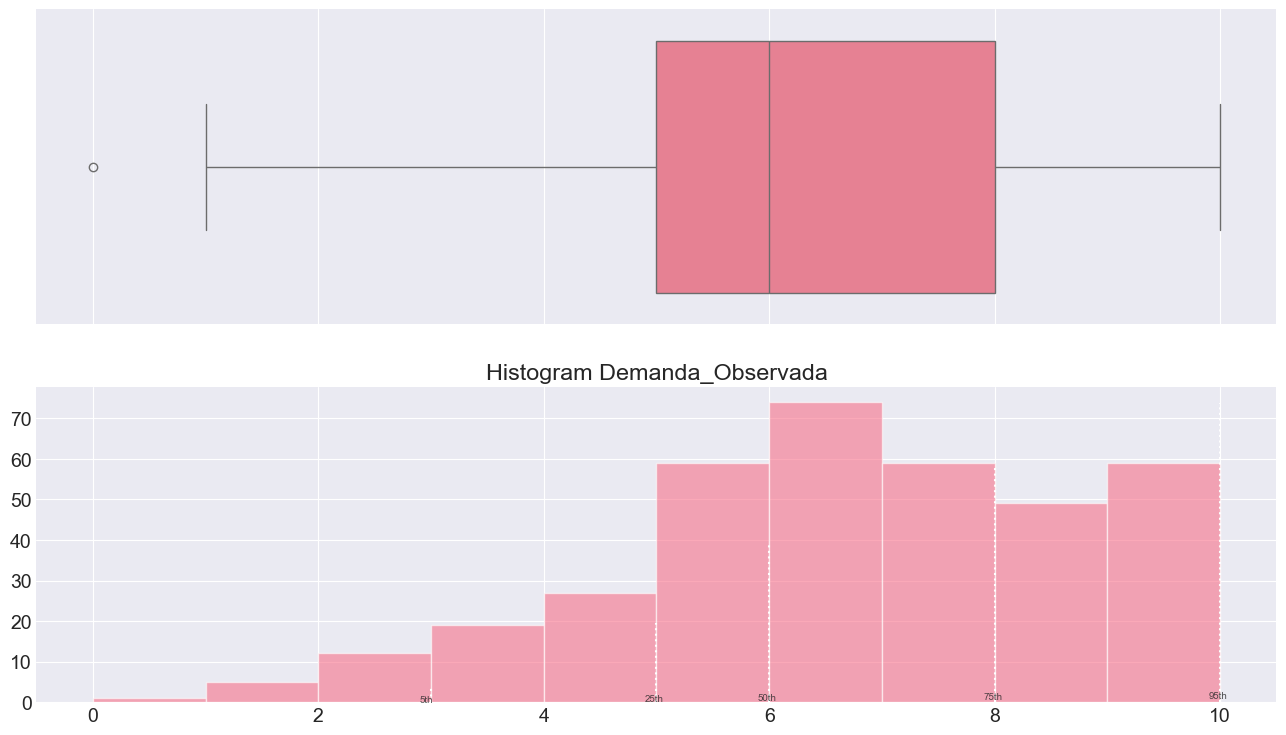

In [12]:
grmt.graph_armor_hist(df_registro_diario, 'Demanda_Observada')

Cola pesada a izquierda, evidencia de datos atípicos, gráficamente no se puede concluir normalidad, se debe pensar en distribuciones diferentes a la distribución normal. Por otro lado tenemos una idea intuitiva gracias al histograma en el cual el cálculo del número de barras da aproximadamente 10, este se basa generalmente en la regla de Sturges: $K = 1 + 3.322log_{10}\left( N \right)$

## Distribución de probabilidad

A partir de los datos de la frecuencia suministrados en el enunciado, calcularemos la
probabilidad simple (frecuencia relativa) y la probabilidad acumulada para cada nivel de demanda.

In [13]:
# Se calcula la probabilidad simple dividiendo los días entre el total de días
tabla_freq['Probabilidad P(X = x)'] = tabla_freq['Dias'] / tabla_freq['Dias'].sum()
# Se calcula la probabilidad acumulada usando el método cumsum()
tabla_freq['Prob_Acumulada F(X ≤ x)'] = tabla_freq['Probabilidad P(X = x)'].cumsum()
# Se redondean los resultados a 4 decimales para mayor claridad al visualizar
tabla_freq['Probabilidad P(X = x)'] = tabla_freq['Probabilidad P(X = x)'].round(4)
tabla_freq['Prob_Acumulada F(X ≤ x)'] = tabla_freq['Prob_Acumulada F(X ≤ x)'].round(4)
total_row = pd.DataFrame([{
    "Ventas": "TOTAL",
    "Dias": sum(numero_dias),
    "Probabilidad P(X = x)": round(sum([n / sum(numero_dias) for n in numero_dias]), 4),
    "Prob_Acumulada F(X ≤ x)":       "",
}])
df_display = pd.concat([tabla_freq, total_row], ignore_index=True)
total_dias = tabla_freq['Dias'].sum()
print(f"\nTotal de días históricos: {total_dias}")


Total de días históricos: 364


Tabla de Distribución de Probabilidades:

In [14]:
# estilo_dashboard_v2(tabla_freq)
estilo_dashboard_v2(df_display)

Ventas,Dias,Probabilidad P(X = x),Prob_Acumulada F(X ≤ x)
0,1,0.00,0.002700
1,5,0.01,0.016500
2,12,0.03,0.049500
3,19,0.05,0.101600
4,27,0.07,0.175800
5,59,0.16,0.337900
6,74,0.20,0.541200
7,59,0.16,0.703300
8,49,0.13,0.837900
9,37,0.10,0.939600


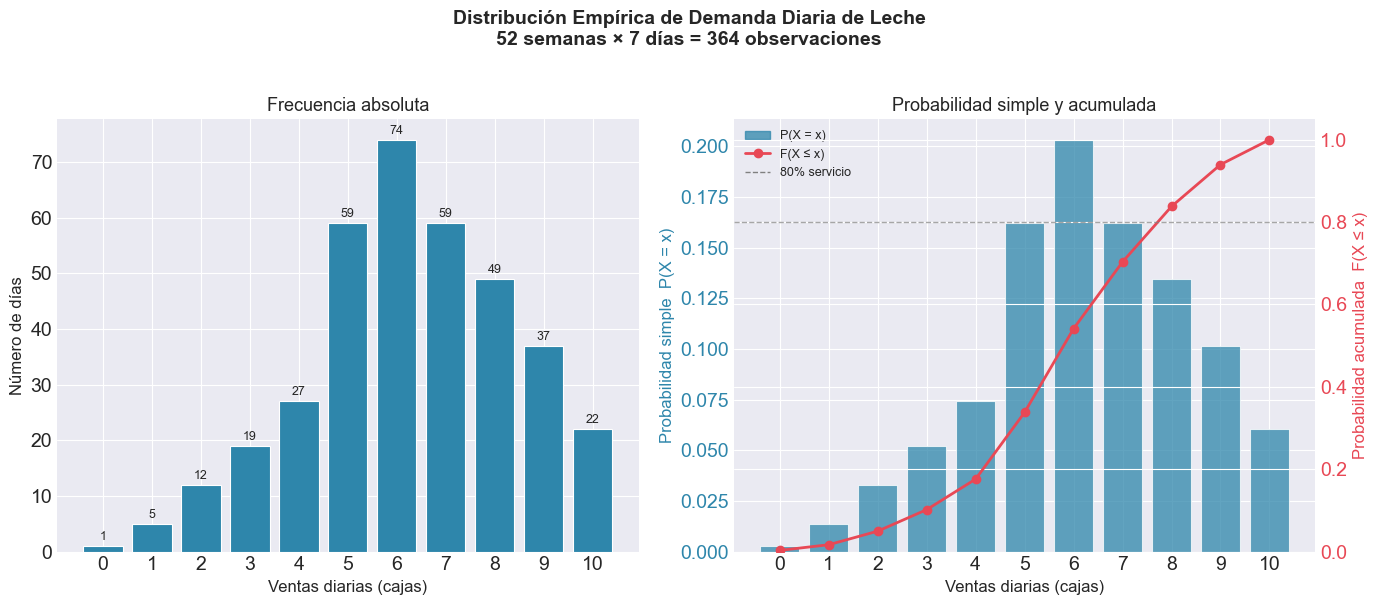

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Distribución Empírica de Demanda Diaria de Leche\n"
    "52 semanas × 7 días = 364 observaciones",
    fontsize=14, fontweight="bold", y=1.01
)

# — Gráfico izquierdo: Histograma de frecuencias absolutas —
# ventas_cajas = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
# numero_dias = np.array([1, 5, 12, 19, 27, 59, 74, 59, 49, 37, 22])
prob = [n / sum(numero_dias) for n in numero_dias]  # P(X = x)
prob_acum = list(np.cumsum(prob))  # F(X ≤ x) acumulada

color_bar = "#2E86AB"
axes[0].bar(ventas_cajas, numero_dias, color=color_bar, edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Ventas diarias (cajas)", fontsize=12)
axes[0].set_ylabel("Número de días", fontsize=12)
axes[0].set_title("Frecuencia absoluta", fontsize=13)
axes[0].set_xticks(ventas_cajas)

# Etiquetas encima de cada barra
for x, n in zip(ventas_cajas, numero_dias):
    axes[0].text(x, n + 0.5, str(n), ha="center", va="bottom", fontsize=9)

# — Gráfico derecho: P(X=x) y F(X≤x) superpuestas —
ax2 = axes[1]
color_prob = "#2E86AB"
color_acum = "#E84855"

bars = ax2.bar(ventas_cajas, prob, color=color_prob, alpha=0.75,
               edgecolor="white", linewidth=0.8, label="P(X = x)")
ax2.set_xlabel("Ventas diarias (cajas)", fontsize=12)
ax2.set_ylabel("Probabilidad simple  P(X = x)", fontsize=12, color=color_prob)
ax2.tick_params(axis="y", labelcolor=color_prob)
ax2.set_xticks(ventas_cajas)
ax2.set_title("Probabilidad simple y acumulada", fontsize=13)

# Eje secundario para F(X ≤ x)
ax2b = ax2.twinx()
ax2b.plot(ventas_cajas, prob_acum, color=color_acum, marker="o",
          linewidth=2, markersize=6, label="F(X ≤ x)")
ax2b.set_ylabel("Probabilidad acumulada  F(X ≤ x)", fontsize=12, color=color_acum)
ax2b.tick_params(axis="y", labelcolor=color_acum)
ax2b.set_ylim(0, 1.05)
ax2b.axhline(y=0.80, color="gray", linestyle="--", linewidth=1,
             alpha=0.7, label="Nivel servicio 80%")

# Leyenda combinada
h1 = mpatches.Patch(color=color_prob, alpha=0.75, label="P(X = x)")
h2 = plt.Line2D([0], [0], color=color_acum, marker="o", linewidth=2, label="F(X ≤ x)")
h3 = plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1, label="80% servicio")
ax2.legend(handles=[h1, h2, h3], loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("D:/SimulAva/notebooks/distribucion.png",
            dpi=150, bbox_inches="tight")
plt.show()

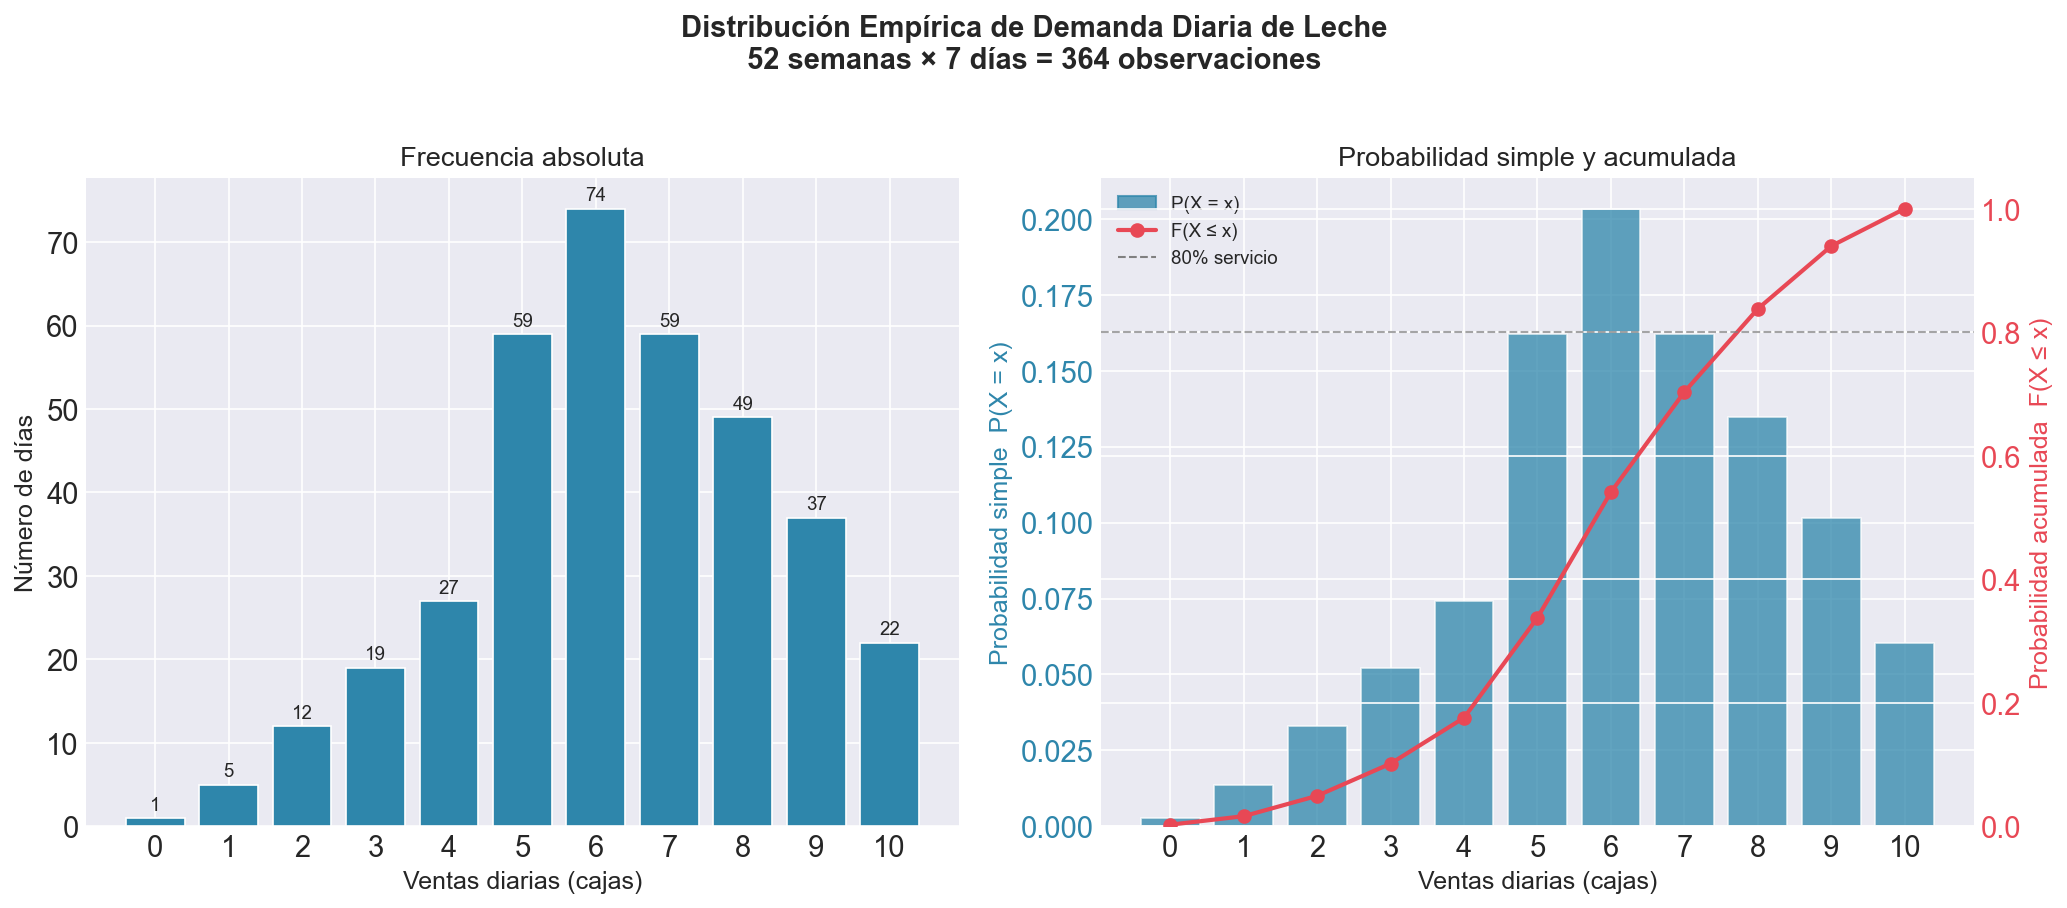

In [16]:
display(Image(filename="D:/SimulAva/notebooks/distribucion.png"))

Para resolver si el administrador debe mantener el contrato actual o si, por el contrario, hacer cambios con el objetivo de que el 80% de los casos no tenga faltantes debemos realizar:
* Función Generadora de Demanda: Esta función recibirá la cantidad de días que queremos simular y el DataFrame con las probabilidades. Su objetivo es devolver un arreglo (array) con valores aleatorios de demanda de cajas de leche, respetando estrictamente la probabilidad de ocurrencia histórica de cada valor.
* Lógica de Simulación de Inventario (Una Semana): Esta función modelará el flujo diario del inventario durante una semana completa (7 días). Recibirá como parámetros la demanda
simulada de la semana, las entregas programadas (ej. pedidos recibidos el lunes y/o miércoles) y el inventario sobrante de la semana anterior. Día a día, sumará las entregas al inventario disponible, restará la demanda y calculará tanto el inventario final como los faltantes, asegurando la regla de negocio de que los faltantes no se acumulan para el día siguiente.

In [17]:
tabla_freq.rename(columns={'Probabilidad P(X = x)': 'Probabilidad', 'Prob_Acumulada F(X ≤ x)': 'Prob_Acumulada'}, inplace=True)
def generar_demanda(n_dias: int, tabla_prob: pd.DataFrame) -> np.ndarray:
    """
    Genera una secuencia de demanda diaria simulada.

    Parámetros:
    - n_dias: Cantidad de días a simular (ej. 7 para una semana).
    - tabla_prob: DataFrame con las columnas 'Ventas' y 'Probabilidad'.

    Retorna:
    - Un array de numpy con las demandas simuladas.
    """

    # Extraer los valores posibles y sus probabilidades del DataFrame
    valores_posibles = tabla_prob['Ventas'].to_numpy()
    probabilidades = tabla_prob['Probabilidad'].to_numpy()
    probabilidades = probabilidades / probabilidades.sum()

    # Generar la demanda usando muestreo aleatorio ponderado
    demandas_simuladas = np.random.choice(
        a=valores_posibles,  # Espacio muestral (0 a 10 cajas)
        size=n_dias,  # Cantidad de números a generar
        replace=True,  # Con reemplazo (los valores pueden repetirse)
        p=probabilidades  # Vector de probabilidades simples
    )

    # Retornar el array con las demandas simuladas
    return demandas_simuladas

In [18]:
# ejemplo
demanda_semana_prueba = generar_demanda(n_dias=7, tabla_prob=tabla_freq)
print(f"Prueba de demanda para 7 días: {demanda_semana_prueba}")

Prueba de demanda para 7 días: [7 6 7 4 6 5 9]


In [19]:
def simular_semana(demanda_semana: np.ndarray | list, entregas_semana: list,
                   inv_inicial: int = 0) -> pd.DataFrame:
    """
    Simula el comportamiento del inventario durante 7 días.

    Parámetros:
    - demanda_semana: Array o lista con la demanda de los 7 días.
    - entregas_semana: Lista con la cantidad de cajas recibidas cada día (7 elementos).
    - inv_inicial: Cajas de leche que sobraron del domingo anterior (por defecto 0).

    Retorna:
    - DataFrame de pandas con el balance diario detallado.
    """

    # Inicializar listas para guardar los resultados de cada día
    inv_final = []
    faltantes = []

    # Variable de estado para llevar el control del inventario
    inv_actual = inv_inicial

    # Bucle iterativo para recorrer los 7 días de la semana (0 al 6 en índices de Python)
    for dia in range(7):
        # El inventario disponible en la mañana incluye la entrega de ese día
        inv_disponible = inv_actual + entregas_semana[dia]

        # Demanda específica de este día
        demanda_hoy = demanda_semana[dia]

        # Evaluar si la demanda supera lo que tenemos disponible
        if demanda_hoy > inv_disponible:
            # Registramos cuántas cajas faltaron para cumplir la demanda
            faltantes.append(demanda_hoy - inv_disponible)
            # El inventario queda vacío (los faltantes no generan inventario negativo)
            inv_actual = 0
        else:
            # Se cubre toda la demanda sin problemas
            faltantes.append(0)
            # Descontamos las cajas vendidas del inventario
            inv_actual = inv_disponible - demanda_hoy

        # Guardamos el inventario con el que cierra este día
        inv_final.append(inv_actual)

    # Consolidar los resultados en un DataFrame para su análisis
    df_resultado = pd.DataFrame({
        'Dia': range(1, 8),
        'Entrega': entregas_semana,
        'Demanda': demanda_semana,
        'Inventario_Final': inv_final,
        'Faltante': faltantes
    })

    return df_resultado

In [20]:
# ejemplo
print("=" * 80)
print("  Prueba de la función con el contrato actual planteado (30 cajas el lunes)")
print("  El proveedor entrega 30 cajas el lunes (Día 1) y 0 el resto de la semana")
print("=" * 80)

entregas_actuales = [30, 0, 0, 0, 0, 0, 0]
prueba_semana_df = simular_semana(
        demanda_semana=demanda_semana_prueba,
        entregas_semana=entregas_actuales,
        inv_inicial=0
    )

  Prueba de la función con el contrato actual planteado (30 cajas el lunes)
  El proveedor entrega 30 cajas el lunes (Día 1) y 0 el resto de la semana


In [21]:
# ejemplo
print("=" * 65)
print("  Balance de inventario para una semana de prueba:")
# print(prueba_semana_df.to_string(index=False))
print("=" * 65)
estilo_dashboard_v2(prueba_semana_df)

  Balance de inventario para una semana de prueba:


Dia,Entrega,Demanda,Inventario_Final,Faltante
1,30,7,23,0
2,0,6,17,0
3,0,7,10,0
4,0,4,6,0
5,0,6,0,0
6,0,5,0,5
7,0,9,0,9


Continuando con el ejercicio, ahora debemos tener en cuenta los costos de inventario y transporte. Para ello plantearemos:
* función evaluar_semana: Esta función tomará como entrada el DataFrame generado por la simulación de la semana y calculará el desempeño financiero y de servicio. Sumará el costo de mantener inventario ($\$800$ por cada caja que quede al final de cada día), calculará el costo de suministro ($\$15,000$ fijos por cada día que haya entrega, más $\$100$ por cada caja entregada), e identificará mediante un valor booleano (True/False) si ocurrió algún faltante durante esa semana. Además, extraerá el inventario final del domingo.

In [22]:
def evaluar_semana(df_semana: pd.DataFrame) -> dict:
    """
    Calcula los costos totales y el nivel de servicio de una semana simulada.

    Parámetros:
    - df_semana: DataFrame con los resultados diarios de 'simular_semana'.

    Retorna:
    - Diccionario con los costos, indicador de faltantes y el inventario de traspaso.
    """

    # --- CÁLCULO DE COSTO DE INVENTARIO ---
    # Se cobra $800 por cada caja que permanezca en inventario al final del día
    total_cajas_guardadas = df_semana['Inventario_Final'].sum()
    costo_inventario = total_cajas_guardadas * 800

    # --- CÁLCULO DE COSTO DE ENTREGA ---
    # El costo fijo de $15,000 se aplica por CADA DÍA que se reciba un pedido (> 0)
    dias_con_entrega = (df_semana['Entrega'] > 0).sum()
    costo_fijo_entrega = dias_con_entrega * 15000

    # El costo variable es de $100 por cada unidad recibida en la semana
    total_cajas_entregadas = df_semana['Entrega'].sum()
    costo_variable_entrega = total_cajas_entregadas * 100

    # Costo total de entrega
    costo_entrega_total = costo_fijo_entrega + costo_variable_entrega

    # --- CÁLCULO DEL COSTO TOTAL ---
    costo_total = costo_inventario + costo_entrega_total

    # --- MÉTRICA DE NIVEL DE SERVICIO ---
    # Evaluamos si hubo al menos un día con faltantes en toda la semana
    hubo_faltante = (df_semana['Faltante'] > 0).any()

    # --- INVENTARIO PARA LA PRÓXIMA SEMANA ---
    # El inventario con el que cierra el domingo (último registro, índice -1)
    inv_final_domingo = df_semana['Inventario_Final'].iloc[-1]

    # 2. Retornar un diccionario con los resultados consolidados
    return {
        'Costo_Inventario': costo_inventario,
        'Costo_Entrega': costo_entrega_total,
        'Costo_Total': costo_total,
        'Hubo_Faltante': hubo_faltante,
        'Inv_Traspaso': inv_final_domingo
    }

In [23]:
# ejemplo
metricas_prueba = evaluar_semana(prueba_semana_df)
print("Métricas calculadas para la semana de prueba:")
for clave, valor in metricas_prueba.items():
    print(f"{clave}: {valor}")

Métricas calculadas para la semana de prueba:
Costo_Inventario: 44800
Costo_Entrega: 18000
Costo_Total: 62800
Hubo_Faltante: True
Inv_Traspaso: 0


Ahora plantearemos una función simular_montecarlo Esta función actuará como el orquestador principal de nuestra simulación. Ejecutará un bucle de 100 iteraciones (representando
100 semanas), y en cada una llamará secuencialmente a las funciones que ya creamos: generará la demanda, simulará el inventario diario y evaluará los costos semanales. Es crucial que esta función pase el inventario final del domingo como el inventario inicial del lunes de la semana siguiente. Al terminar el ciclo, calculará el costo total acumulado y el porcentaje de semanas que lograron no tener faltantes (nivel de servicio).

In [24]:
def simular_montecarlo(q_lunes: int, q_miercoles: int, n_semanas: int,
                       tabla_prob: pd.DataFrame) -> dict:
    """
    Ejecuta la simulación de inventario a lo largo de múltiples semanas continuas.

    Parámetros:
    - q_lunes: Cantidad de cajas a pedir el Lunes (día 1).
    - q_miercoles: Cantidad de cajas a pedir el Miércoles (día 3).
    - n_semanas: Horizonte de simulación en semanas (por defecto 100).
    - tabla_prob: DataFrame con la distribución de probabilidad de la demanda.

    Retorna:
    - Diccionario con los resultados consolidados del horizonte de simulación.
    """

    # Estructurar la lista de entregas para los 7 días (L, M, X, J, V, S, D)
    entregas = [q_lunes, 0, q_miercoles, 0, 0, 0, 0]

    # Inicializar variables para acumular los resultados globales
    costo_total_acumulado = 0
    semanas_con_faltantes = 0

    # Según el documento, la simulación inicia un lunes en la mañana sin inventario previo
    inv_inicial_semana = 0

    # Bucle que recorre cada una de las semanas del horizonte de simulación
    for semana in range(n_semanas):

        # Paso A: Generar la demanda aleatoria para los 7 días de esta semana
        demanda_sem = generar_demanda(n_dias=7, tabla_prob=tabla_prob)

        # Paso B: Simular el flujo de inventario con el inventario inicial correspondiente
        df_semana = simular_semana(
            demanda_semana=demanda_sem,
            entregas_semana=entregas,
            inv_inicial=inv_inicial_semana
        )

        # Paso C: Evaluar los costos y verificar si hubo faltantes en esta semana
        metricas_sem = evaluar_semana(df_semana)

        # Paso D: Acumular el costo total de la semana al gran total
        costo_total_acumulado += metricas_sem['Costo_Total']

        # Si la evaluación indica que hubo faltante, sumar 1 al contador
        if metricas_sem['Hubo_Faltante']:
            semanas_con_faltantes += 1

        # Paso E: El inventario final del domingo pasa a ser el inicial del próximo lunes
        inv_inicial_semana = metricas_sem['Inv_Traspaso']

    # Calcular el porcentaje de semanas SIN faltantes (Nivel de Servicio)
    semanas_sin_faltantes = n_semanas - semanas_con_faltantes
    pct_sin_faltantes = (semanas_sin_faltantes / n_semanas) * 100

    # Retornar el resultado final empaquetado
    return {
        'Q_Lunes': q_lunes,
        'Q_Miercoles': q_miercoles,
        'Costo_Total_100_Sem': costo_total_acumulado,
        'Pct_Sin_Faltantes': pct_sin_faltantes
    }

In [25]:
# ejemplo
resultado_contrato_actual = simular_montecarlo(
    q_lunes=30,
    q_miercoles=0,
    n_semanas=100,
    tabla_prob=tabla_freq
)
print("Resultados de la simulación del contrato actual (30 cajas el lunes) tras 100 semanas:")
for clave, valor in resultado_contrato_actual.items():
    print(f"{clave}: {valor}")

Resultados de la simulación del contrato actual (30 cajas el lunes) tras 100 semanas:
Q_Lunes: 30
Q_Miercoles: 0
Costo_Total_100_Sem: 6359200
Pct_Sin_Faltantes: 1.0


Para dar respuesta a que días debe el administrador pedir las cajas de leche y que cantidad, de tal manera que sea el mínimo costo y que el 80% de los casos no existan faltantes vamos a Definir un rango de posibles cantidades de pedido para los días lunes y miércoles. Luego, iteraremos sobre todas las combinaciones posibles, ejecutando nuestro motor de simulación de 100 semanas para cada par de valores. Finalmente, consolidaremos los resultados en un DataFrame de Pandas para filtrar las estrategias que cumplen la meta de al menos un 80% de semanas sin faltantes y ordenar las opciones viables para encontrar la de menor costo.

In [26]:
# Definir el espacio de búsqueda (Grid Search)
# Posibles pedidos en múltiplos de 5 para simplificar la logística
posibles_lunes = range(20, 75, 5)  # De 20 a 70 cajas
posibles_miercoles = range(0, 55, 5)  # De 0 a 50 cajas

# Lista para guardar los resultados de cada escenario evaluado
resultados_simulacion = []

print(f"Evaluando combinaciones de estrategias. Por favor espere...\n")

# Bucle anidado para evaluar cada combinación de la cuadrícula
for q_l in posibles_lunes:
    for q_m in posibles_miercoles:
        # Ejecutar la simulación para esta combinación (100 semanas)
        # Nota: 'tabla_historica' debe estar en memoria desde el Bloque 1
        resultado_iteracion = simular_montecarlo(
            q_lunes=q_l,
            q_miercoles=q_m,
            n_semanas=100,
            tabla_prob=tabla_freq
        )

        # Agregar el diccionario resultante a nuestra lista
        resultados_simulacion.append(resultado_iteracion)



Evaluando combinaciones de estrategias. Por favor espere...



In [27]:
# Consolidar todos los resultados en un único DataFrame de pandas
df_resultados_totales = pd.DataFrame(resultados_simulacion)

# Filtrar y encontrar la estrategia óptima
# Regla de negocio: Nivel de servicio >= 80%
estrategias_viables = df_resultados_totales[df_resultados_totales['Pct_Sin_Faltantes'] >= 80]

# Ordenar de menor a mayor costo total
analisis_optimo = estrategias_viables.sort_values(by='Costo_Total_100_Sem')

# Mostrar las 5 mejores estrategias viables
print("Top 5 Mejores Estrategias que cumplen la meta (>= 80%):")
# print(analisis_optimo.head(5).to_string(index=False))
estilo_dashboard_v2(analisis_optimo.head(5))



Top 5 Mejores Estrategias que cumplen la meta (>= 80%):


Q_Lunes,Q_Miercoles,Costo_Total_100_Sem,Pct_Sin_Faltantes
40,5,"21,634,000",96.00
35,10,"32,942,000",94.00
20,25,"43,250,800",97.00
45,0,"50,989,200",100.00
25,20,"53,335,600",92.00


In [28]:
# Aislar y mostrar la estrategia campeona (la primera fila tras ordenar)
estrategia_campeona = analisis_optimo.iloc[0]

print("\n" + "=" * 45)
print("LA ESTRATEGIA ÓPTIMA ES:")
print(f"Pedir el Lunes: {int(estrategia_campeona['Q_Lunes'])} cajas")
print(f"Pedir el Miércoles: {int(estrategia_campeona['Q_Miercoles'])} cajas")
print(f"Costo Total (100 sem): ${estrategia_campeona['Costo_Total_100_Sem']:,.2f}")
print(f"Nivel de Servicio: {estrategia_campeona['Pct_Sin_Faltantes']}%")
print("=" * 45 + "\n")


LA ESTRATEGIA ÓPTIMA ES:
Pedir el Lunes: 40 cajas
Pedir el Miércoles: 5 cajas
Costo Total (100 sem): $21,634,000.00
Nivel de Servicio: 96.0%



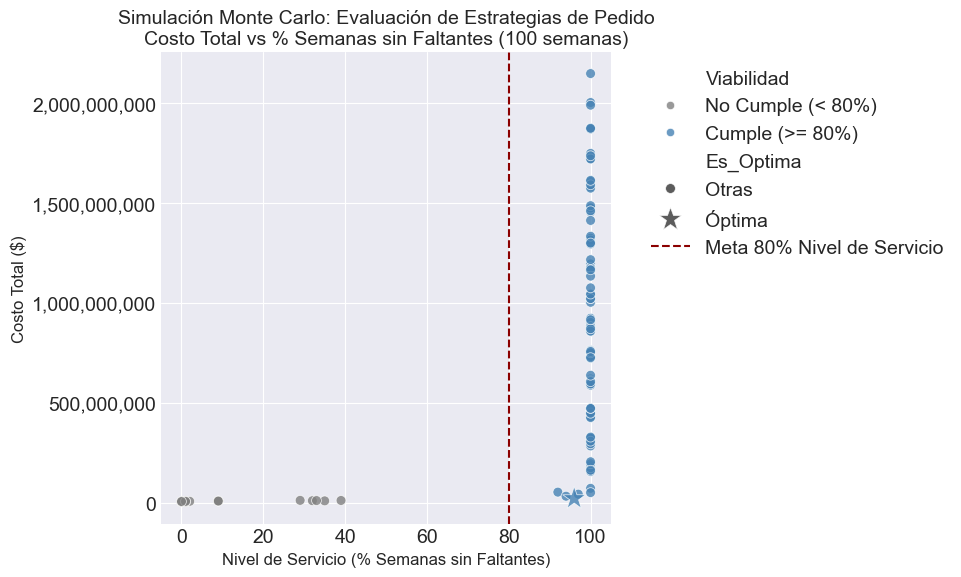

In [29]:
# Preparar los datos para el gráfico
# Clasificar si la estrategia cumple la meta del 80%
df_resultados_totales['Viabilidad'] = np.where(
    df_resultados_totales['Pct_Sin_Faltantes'] >= 80,
    'Cumple (>= 80%)',
    'No Cumple (< 80%)'
)

# Identificar la fila exacta de la estrategia óptima para resaltarla
optimo_mask = (df_resultados_totales['Q_Lunes'] == estrategia_campeona['Q_Lunes']) & \
              (df_resultados_totales['Q_Miercoles'] == estrategia_campeona['Q_Miercoles'])
df_resultados_totales['Es_Optima'] = np.where(optimo_mask, 'Óptima', 'Otras')

# Crear la figura del primer gráfico
plt.figure(figsize=(10, 6))
grafico_dispersion = sns.scatterplot(
    data=df_resultados_totales,
    x='Pct_Sin_Faltantes',
    y='Costo_Total_100_Sem',
    hue='Viabilidad',
    palette={'Cumple (>= 80%)': 'steelblue', 'No Cumple (< 80%)': 'gray'},
    style='Es_Optima',
    markers={'Otras': 'o', 'Óptima': '*'},
    sizes={'Otras': 50, 'Óptima': 300},
    size='Es_Optima',
    alpha=0.8
)

# Añadir la línea de restricción del 80%
plt.axvline(x=80, color='darkred', linestyle='--', label='Meta 80% Nivel de Servicio')

# Configurar textos y leyendas
plt.title(
    "Simulación Monte Carlo: Evaluación de Estrategias de Pedido\nCosto Total vs % Semanas sin Faltantes (100 semanas)",
    fontsize=14)
plt.xlabel("Nivel de Servicio (% Semanas sin Faltantes)", fontsize=12)
plt.ylabel("Costo Total ($)", fontsize=12)
# Ajustar formato del eje Y para mostrar moneda
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar gráfico 1
plt.savefig("D:/SimulAva/notebooks/SMC1.png", dpi=150, bbox_inches="tight")
# plt.show()

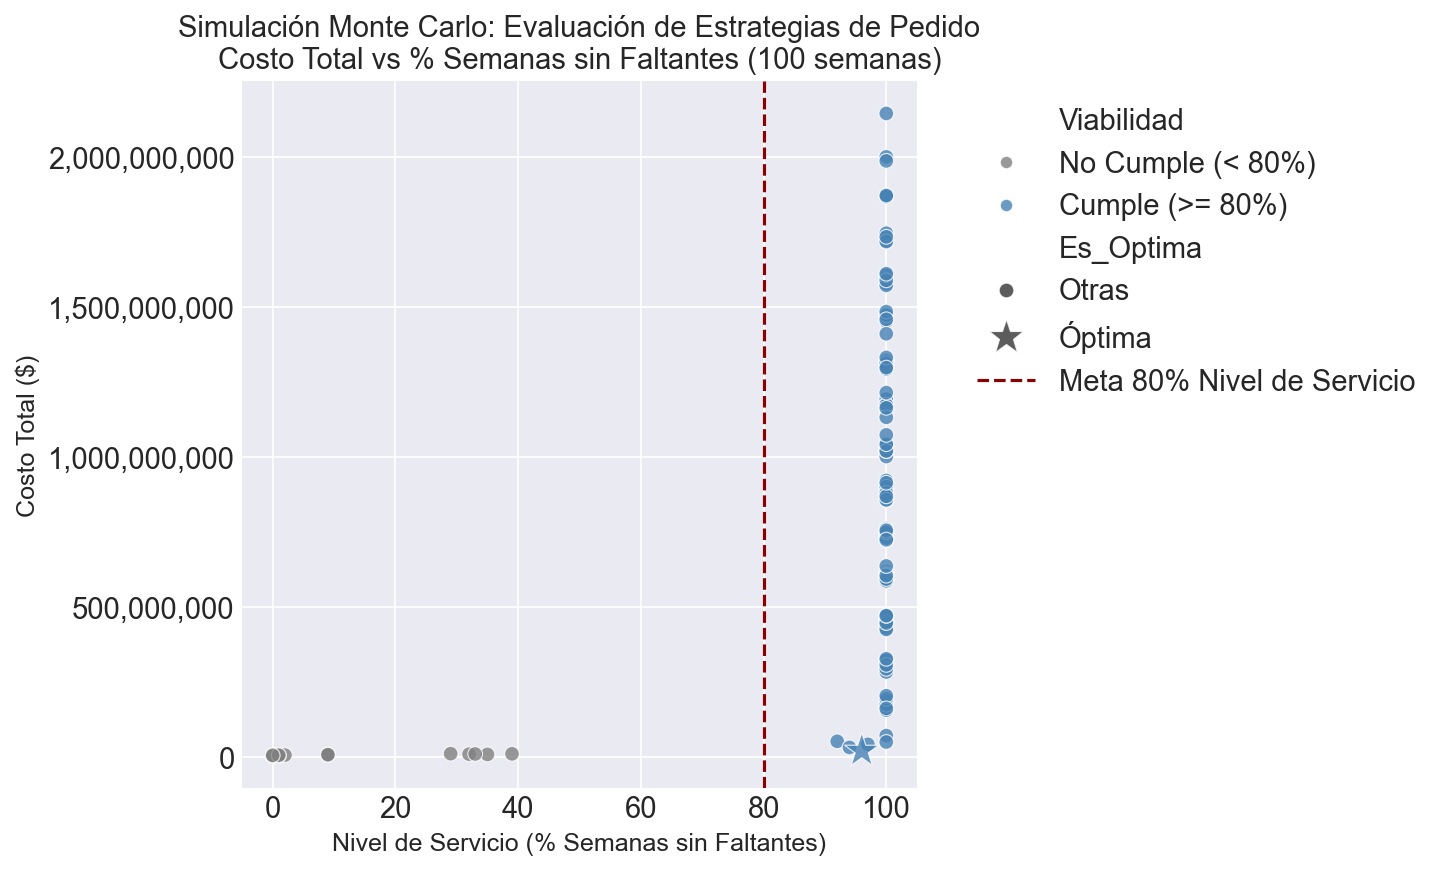

In [30]:
display(Image(filename="D:/SimulAva/notebooks/SMC1.png"))

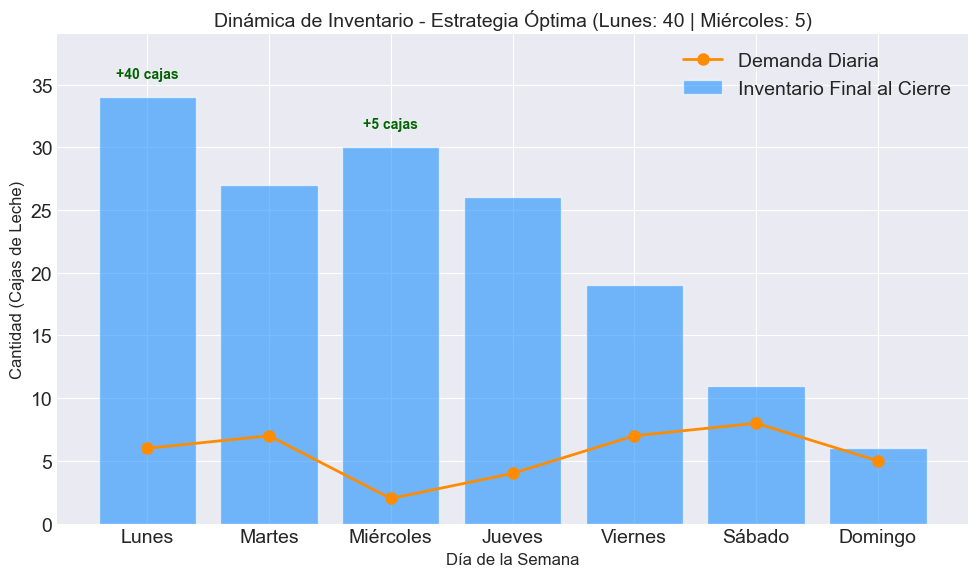

In [31]:
# --- GRÁFICO 2: Comportamiento del Inventario (Semana Típica con Estrategia Óptima) ---

# Extraer las cantidades óptimas
q_lunes_opt = int(estrategia_campeona['Q_Lunes'])
q_miercoles_opt = int(estrategia_campeona['Q_Miercoles'])
entregas_optimas = [q_lunes_opt, 0, q_miercoles_opt, 0, 0, 0, 0]

# Generar una demanda típica para graficar (fijamos semilla para el ejemplo)
np.random.seed(101)
demanda_tipica = generar_demanda(n_dias=7, tabla_prob=tabla_freq)

# Simular esa semana con la estrategia ganadora
df_semana_grafico = simular_semana(
    demanda_semana=demanda_tipica,
    entregas_semana=entregas_optimas,
    inv_inicial=0
)

# Nombres de los días para el eje X
dias_nombres = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# 3. Crear la figura del segundo gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Barras para el inventario final
ax.bar(dias_nombres, df_semana_grafico['Inventario_Final'], color='dodgerblue', alpha=0.6,
       label='Inventario Final al Cierre')

# Línea y puntos para la demanda diaria
ax.plot(dias_nombres, df_semana_grafico['Demanda'], color='darkorange', marker='o', linewidth=2,
        markersize=8, label='Demanda Diaria')

# Añadir anotaciones de texto en los días que hay entregas
for i in range(len(df_semana_grafico)):
    entrega_hoy = df_semana_grafico.loc[i, 'Entrega']
    inv_final = df_semana_grafico.loc[i, 'Inventario_Final']
    if entrega_hoy > 0:
        ax.text(i, inv_final + 1.5, f"+{int(entrega_hoy)} cajas", color='darkgreen',
                fontweight='bold', ha='center', fontsize=10)

# Configurar textos y leyendas
ax.set_title(
    f"Dinámica de Inventario - Estrategia Óptima (Lunes: {q_lunes_opt} | Miércoles: {q_miercoles_opt})",
    fontsize=14)
ax.set_xlabel("Día de la Semana", fontsize=12)
ax.set_ylabel("Cantidad (Cajas de Leche)", fontsize=12)
# Límite Y ligeramente más alto para que quepan las anotaciones
ax.set_ylim(0, max(df_semana_grafico['Inventario_Final'].max(),
                   df_semana_grafico['Demanda'].max()) + 5)
ax.legend(loc='upper right')

plt.tight_layout()

# Mostrar gráfico 2
plt.savefig("D:/SimulAva/notebooks/SMC2.png", dpi=150, bbox_inches="tight")
# plt.show()

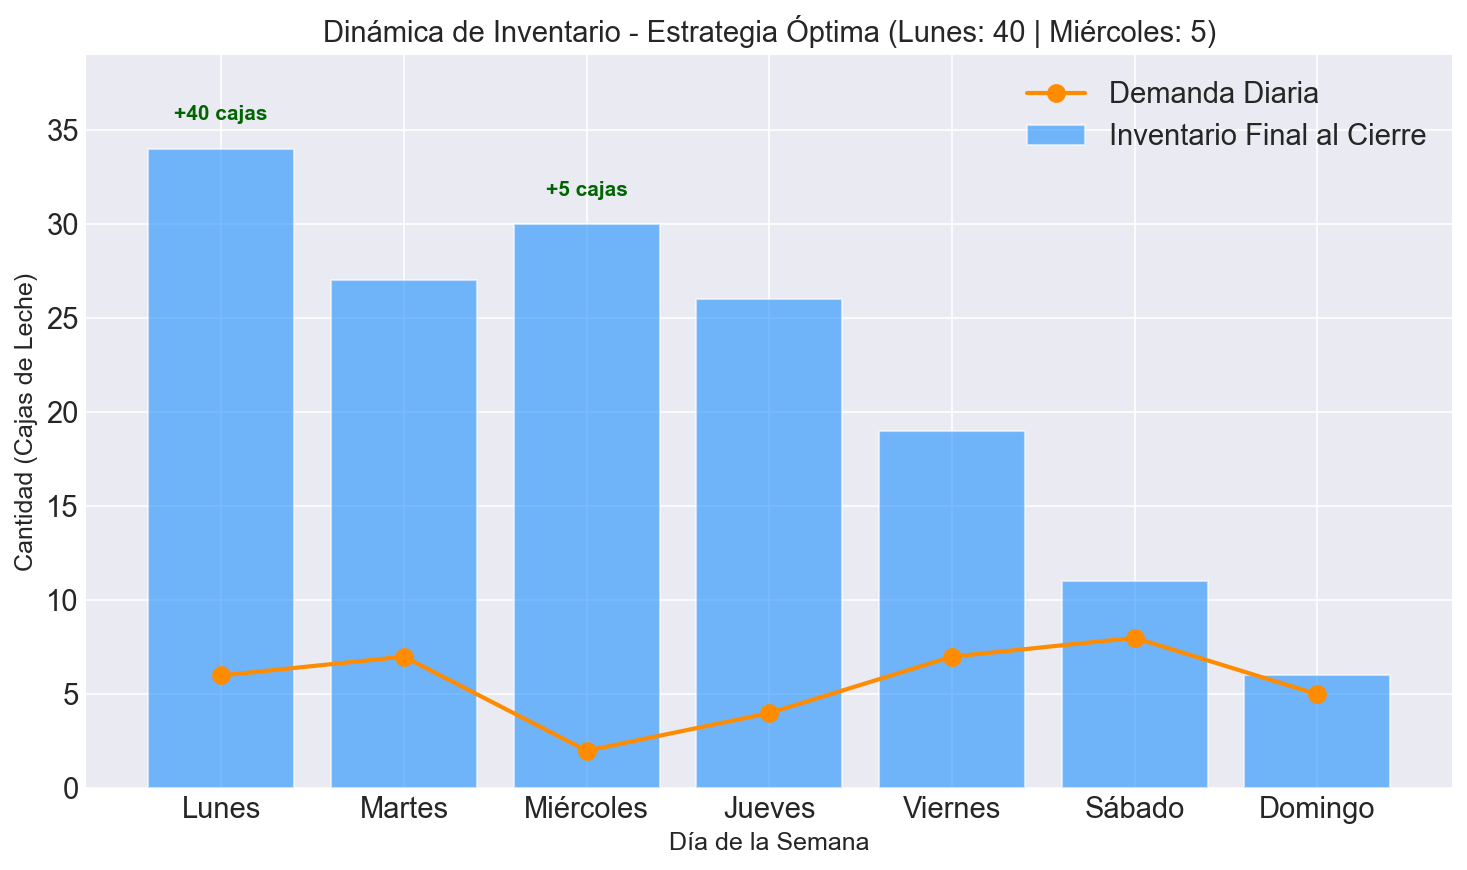

In [32]:
display(Image(filename="D:/SimulAva/notebooks/SMC2.png"))